In this notebook and video, we are going to do three things:

1. Load and use the YAMNet model for inference.

2. Build a new model using the YAMNet embeddings to classify cat and dog sounds.

3. Evaluate and export your model

First we will install [TensorFlow-IO](https://www.tensorflow.org/io)

It will make it easier for you to load audio files off disk.

TensorFlow I/O is a collection of file systems and file formats that are not available in TensorFlow's built-in support.

It provides useful extra Dataset, streaming, and file system extensions, and is maintained by TensorFlow SIG-IO.

In [ ]:
pip install tensorflow-io==0.23.1

Importing the other libraries

In [ ]:
import os

from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_io as tfio

# YAMNet

YAMNet is a pre-trained deep neural network that can predict audio events from 521 classes, such as laughter, barking, or a siren.

## In detail

YAMNet is a pre-trained neural network that employs the MobileNetV1 depthwise-separable convolution architecture. It can use an audio waveform as input and make independent predictions for each of the 521 audio events from the AudioSet corpus.

Internally, the model extracts "frames" from the audio signal and processes batches of these frames. This version of the model uses frames that are 0.96 second long and extracts one frame every 0.48 seconds .

The model accepts a 1-D float32 Tensor or NumPy array containing a waveform of arbitrary length, represented as single-channel (mono) 16 kHz samples in the range [-1.0, +1.0]. This tutorial contains code to help you convert WAV files into the supported format.

The model returns 3 outputs, including the class scores, embeddings (which you will use for transfer learning), and the log mel spectrogram. You can find more details here.

One specific use of YAMNet is as a high-level feature extractor - the 1,024-dimensional embedding output. You will use the base (YAMNet) model's input features and feed them into your shallower model consisting of one hidden tf.keras.layers.Dense layer. Then, you will train the network on a small amount of data for audio classification without requiring a lot of labeled data and training end-to-end. (This is similar to transfer learning for image classification with TensorFlow Hub for more information.)

First, we will test the model and see the results of classifying audio. You will then construct the data pre-processing pipeline.

## Loading YAMNet from TensorFlow Hub

You are going to use a pre-trained YAMNet from Tensorflow Hub to extract the embeddings from the sound files.

Loading a model from TensorFlow Hub is straightforward: choose the model, copy its URL, and use the load function.

In [ ]:
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

With the model loaded, you can follow the YAMNet basic usage tutorial and download a sample WAV file to run the inference.

In [ ]:
testing_wav_file_name = tf.keras.utils.get_file('miaow_16k.wav',
                                                'https://storage.googleapis.com/audioset/miaow_16k.wav',
                                                cache_dir='./',
                                                cache_subdir='test_data')

print(testing_wav_file_name)

We will need a function to load audio files, which will also be used later when working with the training data.

In [ ]:
# Utility functions for loading audio files and making sure the sample rate is correct.

@tf.function
def load_wav_16k_mono(filename):
    """ Load a WAV file, convert it to a float tensor, resample to 16 kHz single-channel audio. """
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(
          file_contents,
          desired_channels=1)
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

In [ ]:
testing_wav_data = load_wav_16k_mono(testing_wav_file_name)

_ = plt.plot(testing_wav_data)

# Play the audio file.
display.Audio(testing_wav_data,rate=16000)

## Load the class mapping

It's important to load the class names that YAMNet is able to recognize. The mapping file is present at yamnet_model.class_map_path() in the CSV format.

In [ ]:
class_map_path = yamnet_model.class_map_path().numpy().decode('utf-8')
class_names =list(pd.read_csv(class_map_path)['display_name'])

for name in class_names[:20]:
  print(name)
print('...')

## Run inference

YAMNet provides frame-level class-scores (i.e., 521 scores for every frame). In order to determine clip-level predictions, the scores can be aggregated per-class across frames (e.g., using mean or max aggregation). This is done below by scores_np.mean(axis=0). Finally, to find the top-scored class at the clip-level, you take the maximum of the 521 aggregated scores.

In [ ]:
scores, embeddings, spectrogram = yamnet_model(testing_wav_data)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.argmax(class_scores)
inferred_class = class_names[top_class]

print(f'The main sound is: {inferred_class}')
print(f'The embeddings shape: {embeddings.shape}')

## ESC-50 dataset

The ESC-50 dataset (Piczak, 2015) is a labeled collection of 2,000 five-second long environmental audio recordings. The dataset consists of 50 classes, with 40 examples per class.

Download the dataset and extract it.

In [ ]:
_ = tf.keras.utils.get_file('esc-50.zip',
                        'https://github.com/karoldvl/ESC-50/archive/master.zip',
                        cache_dir='./',
                        cache_subdir='datasets',
                        extract=True)


## Explore the dataset

The metadata for each file is specified in the csv file at ./datasets/ESC-50-master/meta/esc50.csv

and all the audio files are in ./datasets/ESC-50-master/audio/

You will create a pandas DataFrame with the mapping and use that to have a clearer view of the data.

In [ ]:
esc50_csv = './datasets/ESC-50-master/meta/esc50.csv'
base_data_path = './datasets/ESC-50-master/audio/'

pd_data = pd.read_csv(esc50_csv)
pd_data.head()


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


# Filter the data

Now that the data is stored in the DataFrame, apply some transformations:

1. Filter out rows and use only the selected classes - dog,cat,wind and fireworks. If you want to use any other classes, this is where you can choose them.

2. Amend the filename to have the full path. This will make loading easier later.

3. Change targets to be within a specific range.

In [ ]:
my_classes = ['dog', 'cat','wind','fireworks']
map_class_to_id = {'dog':0, 'cat':1,'wind':2,'fireworks':3}

filtered_pd = pd_data[pd_data.category.isin(my_classes)]

class_id = filtered_pd['category'].apply(lambda name: map_class_to_id[name])
filtered_pd = filtered_pd.assign(target=class_id)

full_path = filtered_pd['filename'].apply(lambda row: os.path.join(base_data_path, row))
filtered_pd = filtered_pd.assign(filename=full_path)

filtered_pd.head(20)


,filename,fold,target,category,esc10,src_file,take
0,./datasets/ESC-50-master/audio/1-100032-A-0.wav,1,0,dog,True,100032,A
14,./datasets/ESC-50-master/audio/1-110389-A-0.wav,1,0,dog,True,110389,A
17,./datasets/ESC-50-master/audio/1-115545-A-48.wav,1,3,fireworks,False,115545,A
18,./datasets/ESC-50-master/audio/1-115545-B-48.wav,1,3,fireworks,False,115545,B
19,./datasets/ESC-50-master/audio/1-115545-C-48.wav,1,3,fireworks,False,115545,C
20,./datasets/ESC-50-master/audio/1-115546-A-48.wav,1,3,fireworks,False,115546,A
37,./datasets/ESC-50-master/audio/1-137296-A-16.wav,1,2,wind,False,137296,A
47,./datasets/ESC-50-master/audio/1-160563-A-48.wav,1,3,fireworks,False,160563,A
48,./datasets/ESC-50-master/audio/1-160563-B-48.wav,1,3,fireworks,False,160563,B
131,./datasets/ESC-50-master/audio/1-25777-A-48.wav,1,3,fireworks,False,25777,A


## Loading the data and retreiving the embeddings

Here you'll apply the load_wav_16k_mono and prepare the WAV data for the model.

When extracting embeddings from the WAV data, you get an array of shape (N, 1024) where N is the number of frames that YAMNet found (one for every 0.48 seconds of audio).

Your model will use each frame as one input. Therefore, you need to create a new column that has one frame per row. You also need to expand the labels and the fold column to proper reflect these new rows.

The expanded fold column keeps the original values. You cannot mix frames because, when performing the splits, you might end up having parts of the same audio on different splits, which would make your validation and test steps less effective.

In [ ]:
filenames = filtered_pd['filename']
targets = filtered_pd['target']
folds = filtered_pd['fold']

main_ds = tf.data.Dataset.from_tensor_slices((filenames, targets, folds))
main_ds.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [ ]:
def load_wav_for_map(filename, label, fold):
  return load_wav_16k_mono(filename), label, fold

main_ds = main_ds.map(load_wav_for_map)
main_ds.element_spec


(TensorSpec(shape=<unknown>, dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [ ]:
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label, fold):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet_model(wav_data)
  num_embeddings = tf.shape(embeddings)[0]
  return (embeddings,
            tf.repeat(label, num_embeddings),
            tf.repeat(fold, num_embeddings))

# extract embedding
main_ds = main_ds.map(extract_embedding).unbatch()
main_ds.element_spec

(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

## Splitting the data

You will use the fold column to split the dataset into train, validation and test sets.

ESC-50 is arranged into five uniformly-sized cross-validation folds, such that clips from the same original source are always in the same fold - find out more in the ESC: Dataset for Environmental Sound Classification paper.

The last step is to remove the fold column from the dataset since you're not going to use it during training.

In [ ]:
cached_ds = main_ds.cache()
train_ds = cached_ds.filter(lambda embedding, label, fold: fold < 4)
val_ds = cached_ds.filter(lambda embedding, label, fold: fold == 4)
test_ds = cached_ds.filter(lambda embedding, label, fold: fold == 5)

# remove the folds column now that it's not needed anymore
remove_fold_column = lambda embedding, label, fold: (embedding, label)

train_ds = train_ds.map(remove_fold_column)
val_ds = val_ds.map(remove_fold_column)
test_ds = test_ds.map(remove_fold_column)

train_ds = train_ds.cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(32).prefetch(tf.data.AUTOTUNE)


## Create the Model

You did most of the work! Next, define a very simple Sequential model with one hidden layer and two outputs to recognize cats and dogs and winds and fireworks from sounds.

In [ ]:
my_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024), dtype=tf.float32,
                          name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(len(my_classes))
], name='my_model')

my_model.summary()


Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 512)               524800    
                                                                 
 dense_5 (Dense)             (None, 4)                 2052      
                                                                 
Total params: 526,852
Trainable params: 526,852
Non-trainable params: 0
_________________________________________________________________


In [ ]:
my_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 optimizer="adam",
                 metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3,
                                            restore_best_weights=True)


In [ ]:
history = my_model.fit(train_ds,
                       epochs=20,
                       validation_data=val_ds,
                       callbacks=callback)


Epoch 1/20
30/30 [==============================] - 13s 17ms/step - loss: 0.9383 - accuracy: 0.8260 - val_loss: 0.6826 - val_accuracy: 0.8938
Epoch 2/20
30/30 [==============================] - 0s 11ms/step - loss: 0.4201 - accuracy: 0.9146 - val_loss: 0.3332 - val_accuracy: 0.9250
Epoch 3/20
30/30 [==============================] - 0s 14ms/step - loss: 0.3795 - accuracy: 0.9354 - val_loss: 0.2541 - val_accuracy: 0.9344
Epoch 4/20
30/30 [==============================] - 0s 12ms/step - loss: 0.2830 - accuracy: 0.9365 - val_loss: 0.1639 - val_accuracy: 0.9406
Epoch 5/20
30/30 [==============================] - 0s 15ms/step - loss: 0.2284 - accuracy: 0.9448 - val_loss: 0.1666 - val_accuracy: 0.9250
Epoch 6/20
30/30 [==============================] - 0s 11ms/step - loss: 0.1917 - accuracy: 0.9552 - val_loss: 0.2121 - val_accuracy: 0.9281
Epoch 7/20
30/30 [==============================] - 0s 15ms/step - loss: 0.1511 - accuracy: 0.9479 - val_loss: 0.2453 - val_accuracy: 0.9344
Epoch 8/20
3

In [ ]:
loss, accuracy = my_model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

10/10 [==============================] - 0s 6ms/step - loss: 0.2213 - accuracy: 0.9250
Loss:  0.22129008173942566
Accuracy:  0.925000011920929


## Testing the model

Next, try your model on the embedding from the previous test using YAMNet only.

In [ ]:
scores, embeddings, spectrogram = yamnet_model(testing_wav_data)
result = my_model(embeddings).numpy()

inferred_class = my_classes[result.mean(axis=0).argmax()]
print(f'The main sound is: {inferred_class}')

The main sound is: cat


## Save a model that can directly take a WAV file as input

Your model works when you give it the embeddings as input.

In a real-world scenario, you'll want to use audio data as a direct input.

To do that, you will combine YAMNet with your model into a single model that you can export for other applications.

To make it easier to use the model's result, the final layer will be a reduce_mean operation. When using this model for serving (which you will learn about later in the tutorial), you will need the name of the final layer. If you don't define one, TensorFlow will auto-define an incremental one that makes it hard to test, as it will keep changing every time you train the model. When using a raw TensorFlow operation, you can't assign a name to it. To address this issue, you'll create a custom layer that applies reduce_mean and call it 'classifier'.

In [ ]:
class ReduceMeanLayer(tf.keras.layers.Layer):
  def __init__(self, axis=0, **kwargs):
    super(ReduceMeanLayer, self).__init__(**kwargs)
    self.axis = axis

  def call(self, input):
    return tf.math.reduce_mean(input, axis=self.axis)

In [ ]:
saved_model_path = './dogs_cats_winds_and_fireworks_yamnet'

input_segment = tf.keras.layers.Input(shape=(), dtype=tf.float32, name='audio')
embedding_extraction_layer = hub.KerasLayer(yamnet_model_handle,
                                            trainable=False, name='yamnet')
_, embeddings_output, _ = embedding_extraction_layer(input_segment)
serving_outputs = my_model(embeddings_output)
serving_outputs = ReduceMeanLayer(axis=0, name='classifier')(serving_outputs)
serving_model = tf.keras.Model(input_segment, serving_outputs)
serving_model.save(saved_model_path, include_optimizer=False)


INFO:tensorflow:Assets written to: ./dogs_cats_winds_and_fireworks_yamnet/assets


INFO:tensorflow:Assets written to: ./dogs_cats_winds_and_fireworks_yamnet/assets


#### lets look at the architecture of the model

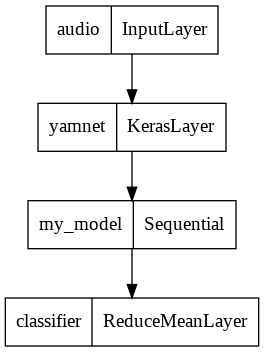

In [ ]:
tf.keras.utils.plot_model(serving_model)

Load your saved model to verify that it works as expected.

In [ ]:
reloaded_model = tf.saved_model.load(saved_model_path)

And for the final test: given some sound data, does your model return the correct result?



In [ ]:
reloaded_results = reloaded_model(testing_wav_data)
cat_or_dog_or_winds_fireworks = my_classes[tf.argmax(reloaded_results)]
print(f'The main sound is: {cat_or_dog_or_winds_fireworks}')

The main sound is: cat


## Lets do some more testing

The model is ready.

Let's compare it to YAMNet on the test dataset.

./datasets/ESC-50-master/audio/3-157695-A-0.wav


Waveform values: [-7.4041084e-10  2.0805353e-09 -1.1156296e-09 ... -2.3461226e-07
  2.9548264e-07 -3.1624134e-07]


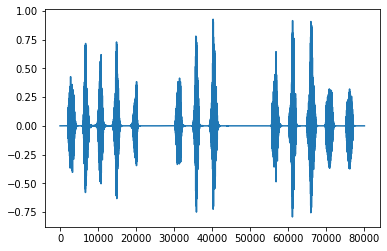

In [ ]:
test_pd = filtered_pd.loc[filtered_pd['fold'] == 3]
row = test_pd.sample(1)
filename = row['filename'].item()
print(filename)
waveform = load_wav_16k_mono(filename)
print(f'Waveform values: {waveform}')
_ = plt.plot(waveform)

display.Audio(waveform, rate=16000)


In [ ]:
# Run the model, check the output.
scores, embeddings, spectrogram = yamnet_model(waveform)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.argmax(class_scores)
inferred_class = class_names[top_class]
top_score = class_scores[top_class]
print(f'[YAMNet] The main sound is: {inferred_class} ({top_score})')

reloaded_results = reloaded_model(waveform)
your_top_class = tf.argmax(reloaded_results)
your_inferred_class = my_classes[your_top_class]
class_probabilities = tf.nn.softmax(reloaded_results, axis=-1)
your_top_score = class_probabilities[your_top_class]
print(f'[Your model] The main sound is: {your_inferred_class} ({your_top_score})')


[YAMNet] The main sound is: Animal (0.6366108059883118)
[Your model] The main sound is: dog (0.999313473701477)
